In [2]:
# ==========================================
# NOTEBOOK 12A
# MECHANISM EXPLORATION
# ==========================================
!pip install pennylane
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svdvals

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 84.4 MB/s eta 0:00:00


In [12]:
# ==========================================
# NOTEBOOK 12A
# GEOMETRIC CONE VALIDATION
# ==========================================

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [13]:
# ==========================================
# BUILD BRICK-WALL GRAPH AT DEPTH L
# ==========================================

def brickwall_edges(n_qubits, depth):

    edges = []

    for d in range(depth):

        if d % 2 == 0:

            for q in range(0, n_qubits-1, 2):

                edges.append((q, q+1))

        else:

            for q in range(1, n_qubits-1, 2):

                edges.append((q, q+1))

    return edges

In [14]:
# ==========================================
# GEOMETRIC CAUSAL CONE
#
# Observable acts on qubits 0...(k-1)
# ==========================================

def geometric_cone_size(n_qubits, k, depth):

    G = nx.Graph()

    G.add_nodes_from(range(n_qubits))

    G.add_edges_from(
        brickwall_edges(
            n_qubits,
            depth
        )
    )

    reachable = set()

    for start in range(k):

        reachable |= nx.node_connected_component(
            G,
            start
        )

    return len(reachable), sorted(reachable)

In [15]:
# ==========================================
# VALIDATION
# ==========================================

print("="*60)
print("GEOMETRIC CONE GROWTH")
print("="*60)

for depth in range(1,11):

    size, nodes = geometric_cone_size(

        n_qubits=10,

        k=1,

        depth=depth

    )

    print(

        f"Depth={depth:2d} | "

        f"Cone={size:2d} | "

        f"Nodes={nodes}"

    )

GEOMETRIC CONE GROWTH
Depth= 1 | Cone= 2 | Nodes=[0, 1]
Depth= 2 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth= 3 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth= 4 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth= 5 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth= 6 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth= 7 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth= 8 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth= 9 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth=10 | Cone=10 | Nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


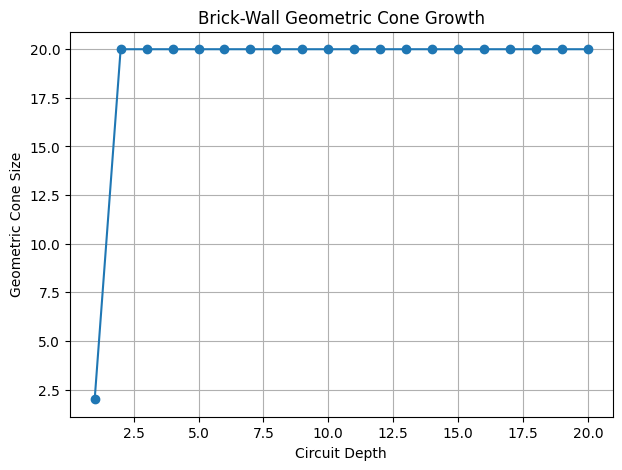

In [16]:
# ==========================================
# VISUALIZE GROWTH
# ==========================================

depths = []

sizes = []

for d in range(1,21):

    s, _ = geometric_cone_size(

        20,

        1,

        d

    )

    depths.append(d)

    sizes.append(s)

plt.figure(figsize=(7,5))

plt.plot(

    depths,

    sizes,

    marker="o"

)

plt.xlabel("Circuit Depth")

plt.ylabel("Geometric Cone Size")

plt.title("Brick-Wall Geometric Cone Growth")

plt.grid(True)

plt.show()

In [17]:
# ==========================================
# GEOMETRIC CAUSAL CONE (BRICK-WALL)
# ==========================================

def geometric_cone_layer_by_layer(n_qubits, measured_qubits, depth):
    """
    Computes the strict geometric backward causal cone of an observable
    at the end of a Brick-Wall Hardware Efficient Ansatz.

    Instead of a static graph, this propagates step-by-step backwards
    in time, respecting the exact CNOT schedule and the speed of light
    (Lieb-Robinson bound) of the circuit.
    """

    # We start by measuring the specified qubits
    # This is the initial "seed" of our backward causal cone.
    reachable = set(measured_qubits)

    # Causal cones for an observable measured at the end must
    # propagate BACKWARDS to see which parameters influence them.
    # We step from the last layer (depth - 1) back down to 0.
    for d in reversed(range(depth)):

        if d % 2 == 0:
            # Even layers: CNOTs on (0,1), (2,3), (4,5)...
            for q in range(0, n_qubits - 1, 2):
                # If either the control or target is inside our causal cone,
                # the gate pulls BOTH qubits into the causal cone.
                if q in reachable or (q + 1) in reachable:
                    reachable.add(q)
                    reachable.add(q + 1)
        else:
            # Odd layers: CNOTs on (1,2), (3,4), (5,6)...
            for q in range(1, n_qubits - 1, 2):
                if q in reachable or (q + 1) in reachable:
                    reachable.add(q)
                    reachable.add(q + 1)

    cone_size = len(reachable)
    cone_fraction = cone_size / n_qubits

    # Return the total volume, the fraction, and the sorted list of qubits inside the causal cone
    return cone_size, cone_fraction, sorted(reachable)

# ==========================================
# GEOMETRIC CONE VALIDATION
# ==========================================
if __name__ == "__main__":
    print("="*60)
    print("BACKWARD GEOMETRIC CONE VALIDATION (n=20, k=1)")
    print("="*60)

    # Let's see how fast a 1-qubit measurement spreads backward
    # Using [0] represents measuring Z0 (k=1)
    k_measured_qubits = [0]

    for d in range(1, 11):
        cone_size, cone_fraction, cone_qubits = geometric_cone_layer_by_layer(
            n_qubits=20,
            measured_qubits=k_measured_qubits,
            depth=d
        )
        print(f"Depth {d:2d} -> cone size {cone_size:2d} (fraction: {cone_fraction:.2f}) | qubits: {cone_qubits}")

BACKWARD GEOMETRIC CONE VALIDATION (n=20, k=1)
Depth  1 -> cone size  2 (fraction: 0.10) | qubits: [0, 1]
Depth  2 -> cone size  2 (fraction: 0.10) | qubits: [0, 1]
Depth  3 -> cone size  4 (fraction: 0.20) | qubits: [0, 1, 2, 3]
Depth  4 -> cone size  4 (fraction: 0.20) | qubits: [0, 1, 2, 3]
Depth  5 -> cone size  6 (fraction: 0.30) | qubits: [0, 1, 2, 3, 4, 5]
Depth  6 -> cone size  6 (fraction: 0.30) | qubits: [0, 1, 2, 3, 4, 5]
Depth  7 -> cone size  8 (fraction: 0.40) | qubits: [0, 1, 2, 3, 4, 5, 6, 7]
Depth  8 -> cone size  8 (fraction: 0.40) | qubits: [0, 1, 2, 3, 4, 5, 6, 7]
Depth  9 -> cone size 10 (fraction: 0.50) | qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Depth 10 -> cone size 10 (fraction: 0.50) | qubits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [18]:
print("\n")
print("="*60)
print("MULTIPLE SUPPORT VALIDATION")
print("="*60)

for k in [1, 2, 4]:

    measured = list(range(k))

    print(f"\nObservable support k={k}")

    for depth in range(1, 7):

        size, frac, nodes = geometric_cone_layer_by_layer(
            n_qubits=20,
            measured_qubits=measured,
            depth=depth
        )

        print(
            f"Depth {depth:2d} -> "
            f"cone={size:2d} "
            f"nodes={nodes}"
        )



MULTIPLE SUPPORT VALIDATION

Observable support k=1
Depth  1 -> cone= 2 nodes=[0, 1]
Depth  2 -> cone= 2 nodes=[0, 1]
Depth  3 -> cone= 4 nodes=[0, 1, 2, 3]
Depth  4 -> cone= 4 nodes=[0, 1, 2, 3]
Depth  5 -> cone= 6 nodes=[0, 1, 2, 3, 4, 5]
Depth  6 -> cone= 6 nodes=[0, 1, 2, 3, 4, 5]

Observable support k=2
Depth  1 -> cone= 2 nodes=[0, 1]
Depth  2 -> cone= 4 nodes=[0, 1, 2, 3]
Depth  3 -> cone= 4 nodes=[0, 1, 2, 3]
Depth  4 -> cone= 6 nodes=[0, 1, 2, 3, 4, 5]
Depth  5 -> cone= 6 nodes=[0, 1, 2, 3, 4, 5]
Depth  6 -> cone= 8 nodes=[0, 1, 2, 3, 4, 5, 6, 7]

Observable support k=4
Depth  1 -> cone= 4 nodes=[0, 1, 2, 3]
Depth  2 -> cone= 6 nodes=[0, 1, 2, 3, 4, 5]
Depth  3 -> cone= 6 nodes=[0, 1, 2, 3, 4, 5]
Depth  4 -> cone= 8 nodes=[0, 1, 2, 3, 4, 5, 6, 7]
Depth  5 -> cone= 8 nodes=[0, 1, 2, 3, 4, 5, 6, 7]
Depth  6 -> cone=10 nodes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [19]:
# ==========================================
# CONE FRACTION TABLE
# ==========================================

import pandas as pd

rows = []

for _, row in dataset.iterrows():

    n = int(row["n"])
    k = int(row["k"])
    tau = int(row["tau"])

    cone_size, cone_fraction, nodes = geometric_cone_layer_by_layer(

        n_qubits=n,

        measured_qubits=list(range(k)),

        depth=tau

    )

    rows.append({

        "n": n,

        "k": k,

        "tau": tau,

        "cone_size": cone_size,

        "cone_fraction": cone_fraction

    })

cone_df = pd.DataFrame(rows)

display(cone_df)

,n,k,tau,cone_size,cone_fraction
0,8,2,21,8,1.000000
1,8,3,17,8,1.000000
2,8,5,10,8,1.000000
3,8,6,5,8,1.000000
4,8,8,3,8,1.000000
5,10,2,17,10,1.000000
6,10,4,11,10,1.000000
7,10,6,4,10,1.000000
8,10,8,2,10,1.000000
9,10,10,2,10,1.000000


In [20]:
print("="*60)

print("Backward Cone Statistics")

print("="*60)

for col in ["cone_size","cone_fraction"]:

    values = cone_df[col]

    cv = values.std()/values.mean()*100

    print(f"{col}")

    print(f"Mean = {values.mean():.3f}")

    print(f"Std  = {values.std():.3f}")

    print(f"CV   = {cv:.2f}%")

    print("-"*40)

Backward Cone Statistics
cone_size
Mean = 9.600
Std  = 1.549
CV   = 16.14%
----------------------------------------
cone_fraction
Mean = 0.967
Std  = 0.093
CV   = 9.67%
----------------------------------------
